# Plot mean + standard deviation of SARGASSO BOUNDING BOX

# Then subtract from eddy

Data generated from generate_PACE_time_series_data.ipynb and generate_background_time_series_data.ipynb

Author: SEL

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates

data=pd.read_csv('PACE_TIMESERIES_BACKGROUND_SARGASSO_EDWARD.csv')
dat = data.sort_values(by='satdate')

# data_eddy=pd.read_csv('PACE_TIMESERIES_MOANA_CHL_POC_164996.csv')
data_eddy=pd.read_csv('PACE_TIMESERIES_MOANA_CHL_POC.csv') #Edward
dat_eddy = data_eddy.sort_values(by='satdate')

In [15]:
dat_eddy=dat_eddy.merge(dat, on='satdate')

In [16]:
dat_eddy

,Unnamed: 0_x,satdate,N_x,chlmean_x,chlstd_x,pocmean_x,pocstd_x,picomean_x,picostd_x,promean_x,...,chlmean_y,chlstd_y,pocmean_y,pocstd_y,picomean_y,picostd_y,promean_y,prostd_y,synmean_y,synstd_y
0,1,20240426,10042,0.223379,0.054780,67.453710,11.131034,16727.5590,8238.76700,397549.44,...,0.156270,0.032409,57.065647,5.312406,7564.34570,2927.82300,377081.30,54280.438,32066.8520,14399.8570
1,2,20240429,13694,0.270173,0.108355,78.408870,18.989225,5874.0110,2478.89380,410659.25,...,0.178631,0.033466,62.553738,6.217144,3224.48000,828.93317,356819.44,39980.434,12882.2670,5914.2890
2,3,20240502,14700,0.269078,0.080546,75.276474,14.916386,8446.4110,4327.92200,238928.84,...,0.140599,0.023410,50.813560,5.129685,2634.45920,580.51450,272539.40,55733.820,12410.7290,4484.7144
3,4,20240504,8025,0.231511,0.061017,67.615486,10.743677,6123.2583,2157.41330,262917.03,...,0.136778,0.028912,48.766090,5.904593,3605.46750,966.35200,265204.03,45713.277,18480.3540,6939.4287
4,6,20240513,14963,0.180805,0.050260,58.014030,10.116494,6436.7950,2760.87060,268791.60,...,0.138774,0.034317,50.699795,5.958785,5007.05900,2065.60820,265288.00,67709.350,24382.9240,10893.7460
5,8,20240524,10625,0.123987,0.034960,48.329353,6.871560,1543.2882,351.12690,269925.50,...,0.109180,0.022995,43.812984,4.808917,2047.32840,562.94990,243735.69,49260.336,15885.0920,5614.5390
6,9,20240601,7696,0.128934,0.034190,42.687386,7.044050,5186.6772,2138.63820,208509.83,...,0.088577,0.012926,34.621250,2.693930,2790.80620,651.99725,180522.75,26236.355,19565.7900,4691.8257
7,10,20240612,6793,0.108133,0.027405,39.898590,5.549083,3586.8135,1274.80880,255434.47,...,0.077798,0.013656,37.097450,2.723888,2441.37300,437.03757,271776.66,44827.930,18983.3160,4532.2207
8,11,20240619,8620,0.086770,0.024396,40.956745,4.646462,2355.4050,640.34595,281057.60,...,0.069392,0.009659,37.865536,3.488963,2252.93210,436.97770,257184.47,56147.934,20186.4900,5850.6000
9,12,20240621,7504,0.081145,0.020291,36.822803,4.533034,2074.7542,613.36865,252439.89,...,0.064855,0.007364,33.791298,2.686635,1825.09060,318.63330,221215.58,34202.445,16566.6820,3845.3674


In [17]:
# Set default fontsizes for plots
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

In [18]:
dates1=dat_eddy.satdate.values
dates=[];
for IDX in range(0,len(dates1)):
    date2 = datetime.strptime(str(dates1[IDX]), '%Y%m%d').strftime('%m/%d/%Y')
    dates.append(date2);

In [20]:
values=dat_eddy.pocmean_x.values-dat_eddy.pocmean_y.values
df = pd.DataFrame({'date': dates, 'value': values})
datetimes = pd.to_datetime(df['date'])  # Convert date column to datetime

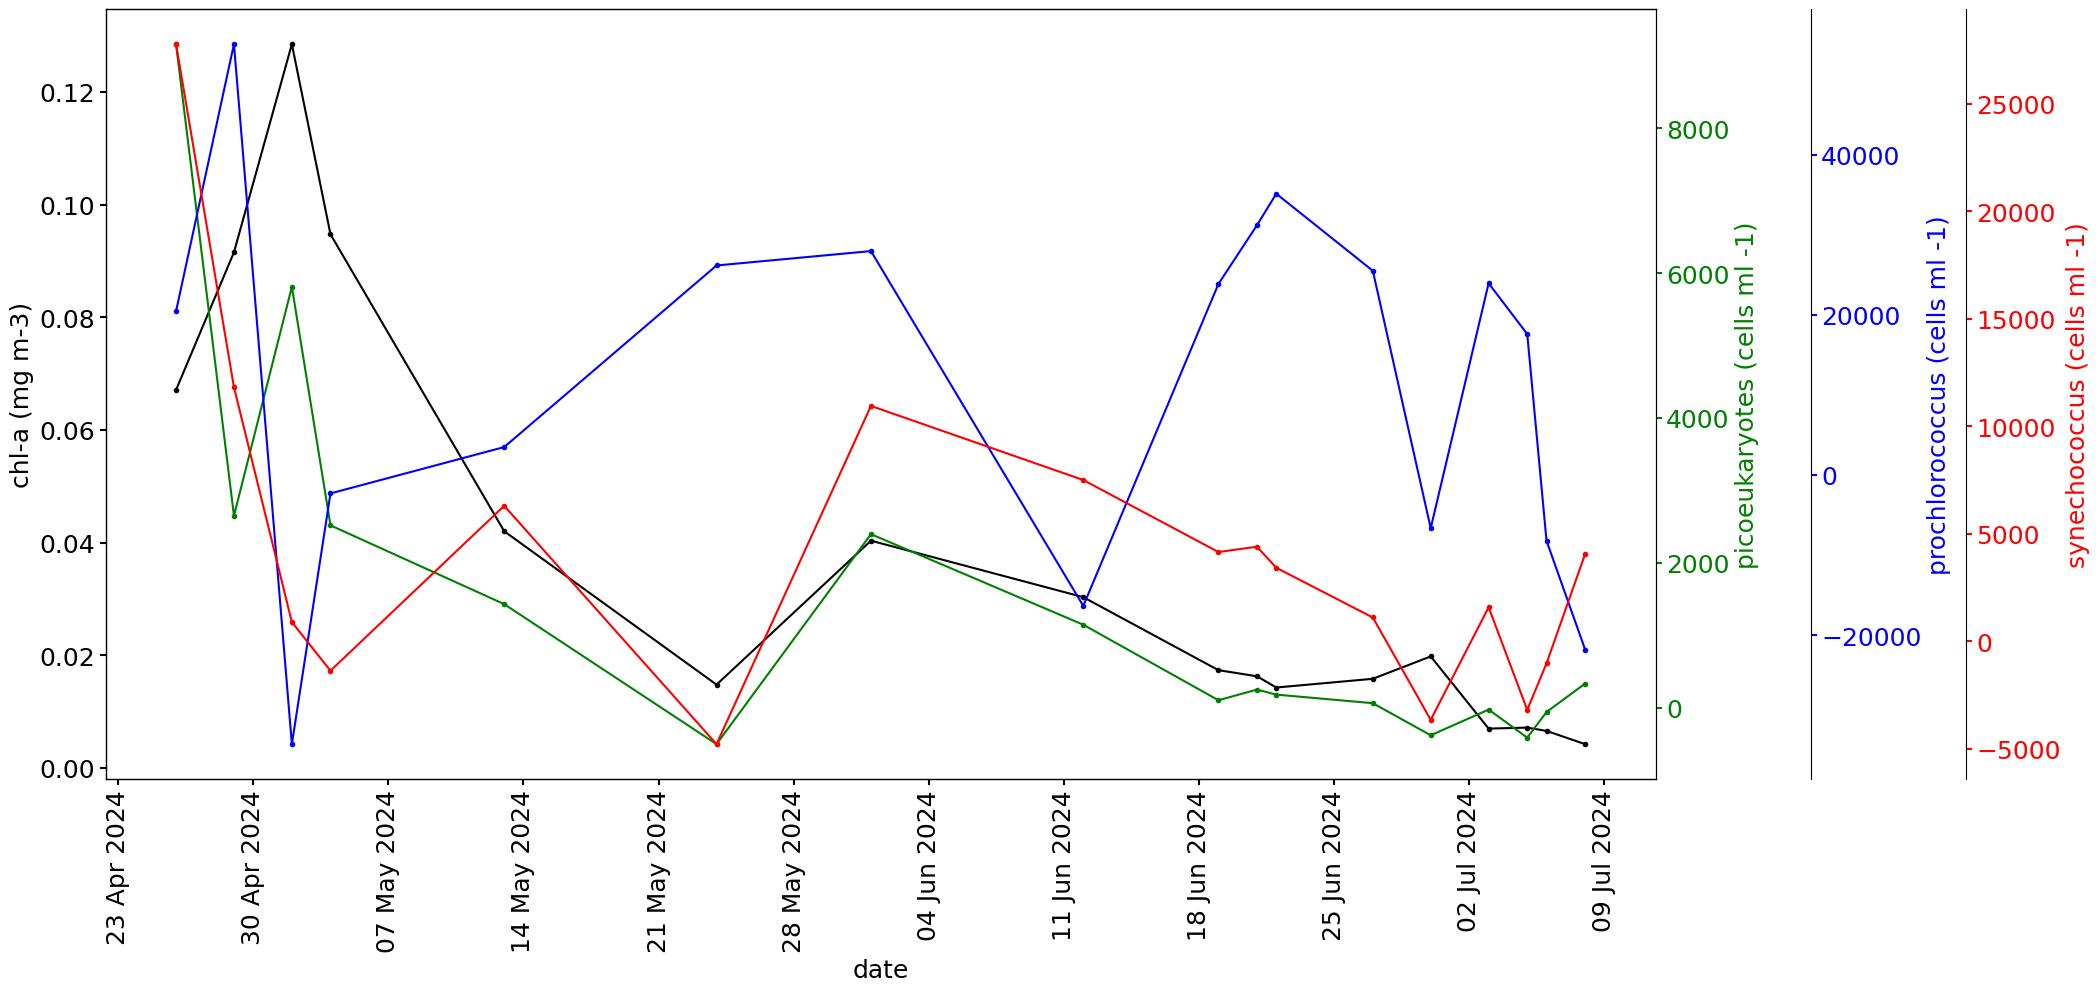

In [21]:
fig, ax = plt.subplots(figsize=(20,10))
# fig, (ax, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(20,5))

fig.subplots_adjust(right=0.9)

twin = ax.twinx()
twin1 = ax.twinx()
twin2 = ax.twinx()

# Offset the right spine of twin2.  The ticks and label have already been
# placed on the right by twinx above.
twin.spines.right.set_position(("axes", 1))
twin1.spines.right.set_position(("axes", 1.1))
twin2.spines.right.set_position(("axes", 1.2))

p, = ax.plot(datetimes,dat_eddy.chlmean_x-dat_eddy.chlmean_y, "k-", label="chl-a")
ax.plot(datetimes,dat_eddy.chlmean_x-dat_eddy.chlmean_y, "k.", label="chl-a")
p1, = twin.plot(datetimes,dat_eddy.picomean_x-dat_eddy.picomean_y, "g-", label="picoeukaryotes")
twin.plot(datetimes,dat_eddy.picomean_x-dat_eddy.picomean_y, "g.", label="picoeukaryotes")
p2, = twin1.plot(datetimes,dat_eddy.promean_x-dat_eddy.promean_y, "b-", label="prochlorococcus")
twin1.plot(datetimes,dat_eddy.promean_x-dat_eddy.promean_y, "b.", label="prochlorococcus")
p3, = twin2.plot(datetimes,dat_eddy.synmean_x-dat_eddy.synmean_y, "r-", label="synechococcus")
twin2.plot(datetimes,dat_eddy.synmean_x-dat_eddy.synmean_y, "r.", label="synechococcus")
# twin2.plot(alongtrack,median_filter(syn_grid[350,:],10), "r-", label="synechococcus")

# ax.set_xlim(0,400)
# ax.set_ylim(0,1)
# # twin.set_xlim(0,400)
# twin.set_ylim(0,40000)
# twin1.set_ylim(100000, 550000)
# # twin1.set_xlim(0,400)
# twin2.set_ylim(1, 250000)
# twin2.set_xlim(0,400)

ax.tick_params(axis='x', rotation=90)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

ax.set_xlabel("date")
ax.set_ylabel("chl-a (mg m-3)")
twin.set_ylabel("picoeukaryotes (cells ml -1)")
twin1.set_ylabel("prochlorococcus (cells ml -1)")
twin2.set_ylabel("synechococcus (cells ml -1)")

ax.yaxis.label.set_color(p.get_color())
twin.yaxis.label.set_color(p1.get_color())
twin1.yaxis.label.set_color(p2.get_color())
twin2.yaxis.label.set_color(p3.get_color())

tkw = dict(size=4, width=1.5)
ax.tick_params(axis='y', colors=p.get_color(), **tkw)
twin.tick_params(axis='y', colors=p1.get_color(), **tkw)
twin1.tick_params(axis='y', colors=p2.get_color(), **tkw)
twin2.tick_params(axis='y', colors=p3.get_color(), **tkw)
ax.tick_params(axis='x', **tkw)

# ax.legend(handles=[p, p1, p2, p3])

plt.show()

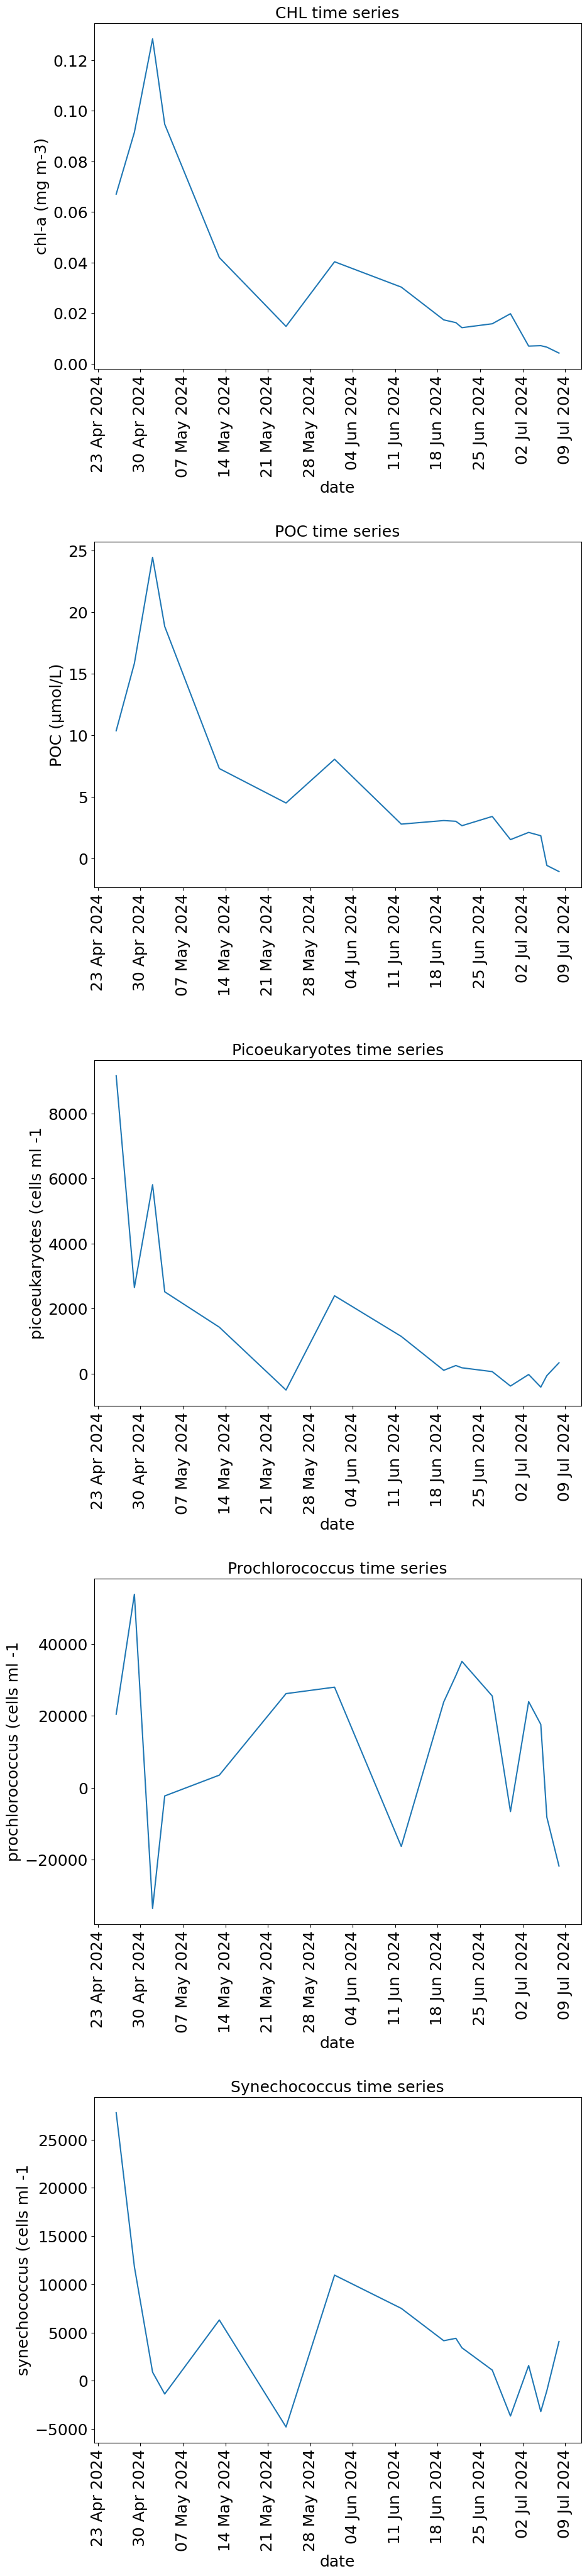

In [23]:
fig, (ax, ax2, ax3, ax4, ax5) = plt.subplots(5,1, figsize=(10,50))

# Plot for CHL
values=dat_eddy.chlmean_x.values-dat_eddy.chlmean_y.values
# errors=dat_eddy.chlstd.values-dat_eddy.chlmean.values #???
df = pd.DataFrame({'date': dates, 'value': values})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
plt.xticks(rotation=90)
##ax.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax.plot(df['date'], df['value'])
ax.set_xlabel('date')
ax.set_ylabel('chl-a (mg m-3)')
ax.set_title('CHL time series')
ax.tick_params(axis='x', rotation=90)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Set interval to 2 weeks
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for POC
values=dat_eddy.pocmean_x.values-dat_eddy.pocmean_y.values
# errors=dat_eddy.pocstd.values-dat_eddy.pocmean.values
df = pd.DataFrame({'date': dates, 'value': values})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
# Plot the time series with error bars
plt.xticks(rotation=90)
# ax2.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax2.plot(df['date'], df['value'])
ax2.set_ylabel("date")
ax2.set_ylabel("POC (µmol/L)")
ax2.set_title('POC time series')
ax2.tick_params(axis='x', rotation=90)
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for Picoeukaryotes
values=dat_eddy.picomean_x.values-dat_eddy.picomean_y.values
# errors=dat_eddy.picostd.values-dat_eddy.picomean.values
df = pd.DataFrame({'date': dates, 'value': values})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
plt.xticks(rotation=90)
# ax3.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax3.plot(df['date'], df['value'])
ax3.set_xlabel('date')
ax3.set_ylabel('picoeukaryotes (cells ml -1')
ax3.set_title('Picoeukaryotes time series')
ax3.tick_params(axis='x', rotation=90)
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for Prochlorococcus
values=dat_eddy.promean_x.values-dat_eddy.promean_y.values
# errors=dat_eddy.prostd.values-dat_eddy.promean.values
df = pd.DataFrame({'date': dates, 'value': values})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
plt.xticks(rotation=90)
# ax4.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax4.plot(df['date'], df['value'])
ax4.set_xlabel('date')
ax4.set_ylabel('prochlorococcus (cells ml -1')
ax4.set_title('Prochlorococcus time series')
ax4.tick_params(axis='x', rotation=90)
ax4.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for Synechococcus
values=dat_eddy.synmean_x.values-dat_eddy.synmean_y.values
# errors=dat_eddy.synstd.values-dat_eddy.synmean.values
df = pd.DataFrame({'date': dates, 'value': values})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
# ax5.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax5.plot(df['date'], df['value'])
ax5.set_xlabel('date')
ax5.set_ylabel('synechococcus (cells ml -1')
ax5.set_title('Synechococcus time series')
ax5.tick_params(axis='x', rotation=90)
ax5.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

plt.subplots_adjust(hspace=0.5)  # Increase the vertical space between subplots
plt.show()